# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

# Uploading Data

In [2]:
df = pd.read_csv("ai_ds_job_salaries_2026_cleaned.csv")

X = df.drop("salary_usd", axis=1)
y = df["salary_usd"]

df["uses_ai_tools_daily"] = df["uses_ai_tools_daily"].astype(int)

df.head()

,job_title,experience_level,employment_type,company_size,industry,company_location_name,remote_ratio,years_experience,education_level,primary_language,team_size,certifications_count,uses_ai_tools_daily,ai_tools_hours_per_week,salary_usd
0,Data Analyst,Lead,Part-time,S,Finance,India,0,14,Bachelors,Python,5,0,1,12,23844
1,Research Scientist,Senior,Full-time,L,Retail,United States,50,8,Masters,SQL,6,1,0,2,170132
2,Machine Learning Engineer,Entry,Full-time,M,Government,United States,0,0,Bootcamp,Python,4,1,1,5,83059
3,Data Engineer,Senior,Full-time,M,Government,Brazil,100,10,Masters,Java,6,2,1,2,29531
4,Data Engineer,Mid,Full-time,M,Education,United States,0,3,Bachelors,Python,13,2,0,4,70105


# Train Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=30)

# Categorical Columns

In [4]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['job_title', 'experience_level', 'employment_type', 'company_size', 'industry', 'company_location_name', 'education_level', 'primary_language']


# Validation Set

In [5]:
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

# Building and Training CatBoost Model

In [6]:
cb = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, cat_features=categorical_cols,
                        l2_leaf_reg=3.0, early_stopping_rounds=30, random_state=42, verbose=False)

start_time = time.time()
cb.fit(X_train_final, y_train_final, eval_set=(X_val, y_val), use_best_model=True)
end_time = time.time()

training_time = end_time - start_time
print("Training Time is : ", training_time, " Seconds")

Training Time is :  15.627822160720825  Seconds


# Prediction

In [7]:
train_pred_cb = cb.predict(X_train)
y_pred_cb = cb.predict(X_test)

# Evaluation

In [8]:
r2_train_cb = r2_score(y_train, train_pred_cb)
r2_cb = r2_score(y_test, y_pred_cb)

mae_train_cb = mean_absolute_error(y_train, train_pred_cb)
mae_cb = mean_absolute_error(y_test, y_pred_cb)

mse_train_cb = mean_squared_error(y_train, train_pred_cb)
mse_cb = mean_squared_error(y_test, y_pred_cb)

rmse_cb = np.sqrt(mse_cb)

# CatBoost Results

In [9]:
print("R2 train=", r2_train_cb)
print("R2 Score=", r2_cb)
print("MAE_train=", mae_train_cb)
print("MAE=", mae_cb)
print("MSE_train =", mse_train_cb)
print("MSE =", mse_cb)
print("RMSE=", rmse_cb)

R2 train= 0.8880470317881387
R2 Score= 0.863958579632465
MAE_train= 13141.836329716547
MAE= 14654.325262582477
MSE_train = 339574891.704284
MSE = 430024509.89004695
RMSE= 20737.032330833816


# Actual vs Predicted

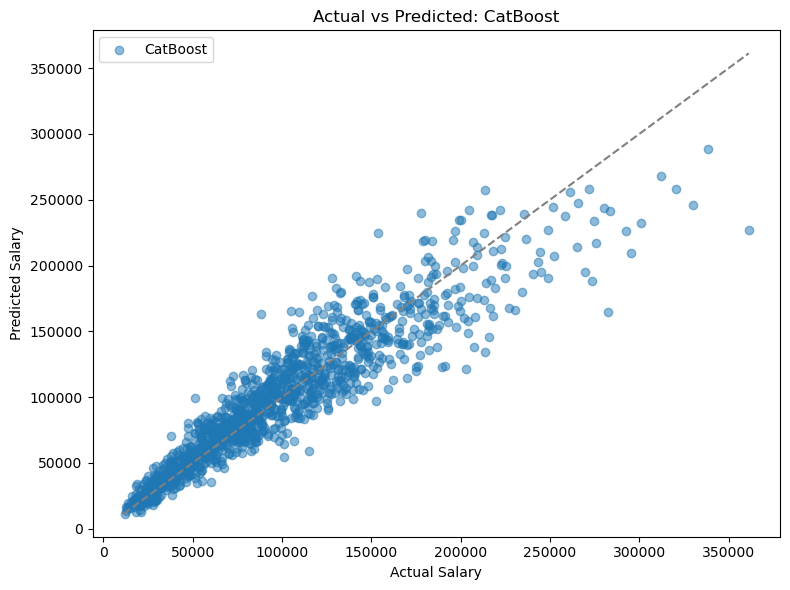

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_cb, alpha=0.5, label="CatBoost")
min_v = min(y_test.min(), y_pred_cb.min())
max_v = max(y_test.max(), y_pred_cb.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--", color="gray")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted: CatBoost")
plt.legend()
plt.tight_layout()
plt.savefig("catboost_actual_vs_predicted.png", dpi=150)
plt.show()

# Feature Importance

In [11]:
importance_cb = pd.Series(cb.get_feature_importance(), index=X_train.columns, name="CatBoost")
importance_cb = importance_cb.sort_values(ascending=False)
importance_cb.head(10)

company_location_name      39.505506
experience_level           28.013818
job_title                   8.430774
company_size                5.110318
employment_type             4.921295
industry                    4.702289
years_experience            3.774034
education_level             3.026213
ai_tools_hours_per_week     0.641871
primary_language            0.561169
Name: CatBoost, dtype: float64

# Feature Importance Chart (Vertical) - for Power BI

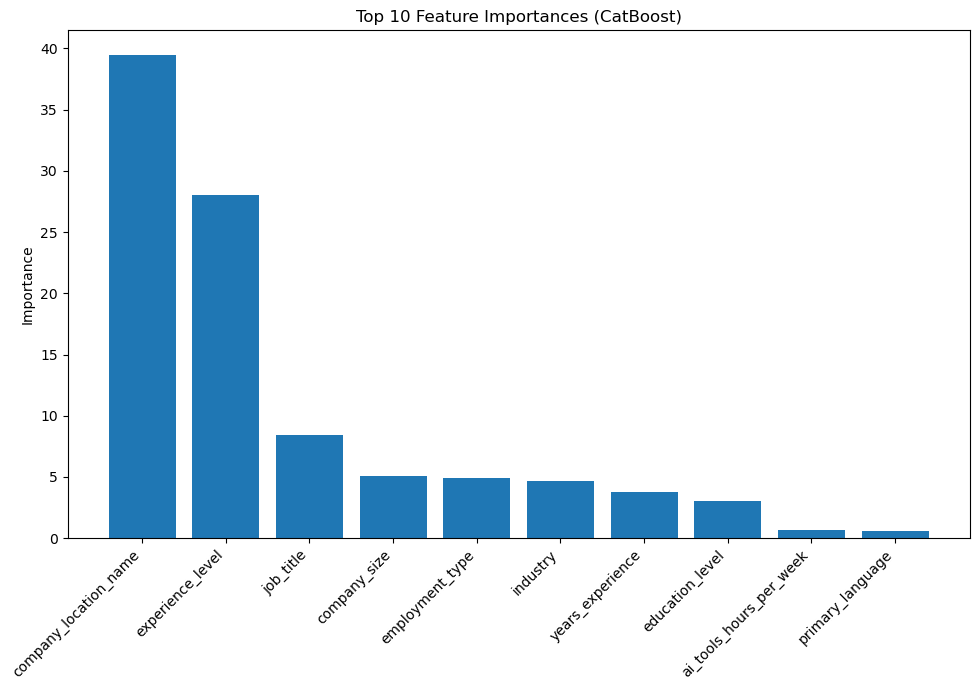

,Feature,Importance
0,company_location_name,39.505506
1,experience_level,28.013818
2,job_title,8.430774
3,company_size,5.110318
4,employment_type,4.921295
5,industry,4.702289
6,years_experience,3.774034
7,education_level,3.026213
8,ai_tools_hours_per_week,0.641871
9,primary_language,0.561169


In [12]:
# Top 10 Feature Importances - CatBoost (vertical bars)
top10_cb = importance_cb.head(10)

plt.figure(figsize=(10, 7))
plt.bar(top10_cb.index, top10_cb.values, color="#1f77b4")
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances (CatBoost)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("catboost_feature_importance.png", dpi=150)
plt.show()

# Export the data so it can be loaded straight into Power BI
powerbi_df = top10_cb.reset_index()
powerbi_df.columns = ["Feature", "Importance"]
powerbi_df.to_csv("catboost_feature_importance.csv", index=False)
powerbi_df

# Save Predictions (optional)

In [13]:
df_result = pd.DataFrame({
    "y_test": y_test,
    "y_pred": y_pred_cb
})

df_result.to_csv("prediction_results_CatBoost.csv", index=False)

# Export Model + Metadata (for the Web App)

In [14]:
import json

# 1) Save the trained CatBoost model to a file
cb.save_model("catboost_model.cbm")

# 2) Save metadata the web app needs to build the form:
#    - the exact column order the model expects
#    - which columns are categorical vs numeric
#    - the list of valid values for each categorical column (for dropdowns)
numeric_cols = [c for c in X.columns if c not in categorical_cols]

metadata = {
    "columns": list(X.columns),
    "categorical_cols": categorical_cols,
    "numeric_cols": numeric_cols,
    "categorical_options": {
        col: sorted(X[col].dropna().unique().tolist(), key=str) for col in categorical_cols
    },
    "numeric_ranges": {
        col: {"min": float(X[col].min()), "max": float(X[col].max()), "default": float(X[col].median())}
        for col in numeric_cols
    }
}

with open("model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved catboost_model.cbm and model_metadata.json")

Saved catboost_model.cbm and model_metadata.json
